<a href="https://colab.research.google.com/github/24Priyanshi/period-tracker/blob/main/mensturalTracker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

# 1. Load data
hormones = pd.read_csv('/content/drive/MyDrive/MensturalTracker/hormones_and_selfreport.csv')
active = pd.read_csv('/content/drive/MyDrive/MensturalTracker/active_minutes.csv')
stress = pd.read_csv('/content/drive/MyDrive/MensturalTracker/stress_score.csv')

# 2. Aggregate Stress (take the mean per day per user)
stress_daily = stress.groupby(['id', 'study_interval', 'day_in_study'])['stress_score'].mean().reset_index()

# 3. Encode the symptoms (Simplified mapping)
mapping = {'Not at all': 0, 'Very Low/Little': 1, 'Low': 1, 'Moderate': 2, 'High': 3, 'Very High': 4}
symptom_cols = ['cramps', 'fatigue', 'moodswing', 'stress', 'bloating']

for col in symptom_cols:
    if col in hormones.columns:
        hormones[col] = hormones[col].map(mapping).fillna(0)

# 4. Merge everything
# We use 'inner' or 'left' join based on hormones as it is our primary source
df_final = hormones.merge(active[['id', 'day_in_study', 'sedentary', 'lightly']], on=['id', 'day_in_study'], how='left')
df_final = df_final.merge(stress_daily, on=['id', 'day_in_study'], how='left')

# Drop columns we don't need for the LSTM right now
df_final = df_final.drop(columns=['flow_color', 'flow_volume', 'is_weekend_x', 'is_weekend_y'], errors='ignore')

print(f"Final dataset shape: {df_final.shape}")
df_final.head()

Final dataset shape: (5730, 24)


,id,study_interval_x,is_weekend,day_in_study,phase,lh,estrogen,pdg,appetite,exerciselevel,...,sleepissue,moodswing,stress,foodcravings,indigestion,bloating,sedentary,lightly,study_interval_y,stress_score
0,1,2022,True,1,Follicular,2.9,94.2,NaN,Low,Low,...,Low,1.0,2.0,Very Low/Little,Very Low/Little,1.0,753.0,64.0,NaN,NaN
1,1,2022,False,2,Follicular,1.2,226.3,NaN,Low,Low,...,Very High,1.0,2.0,Very Low/Little,Very Low/Little,1.0,855.0,74.0,NaN,NaN
2,1,2022,False,3,Follicular,3.5,276.8,NaN,Very Low,Very Low,...,Very High,1.0,1.0,Very Low/Little,Very Low/Little,1.0,751.0,134.0,NaN,NaN
3,1,2022,False,4,Fertility,1.8,322.1,NaN,Low,Low,...,Very High,1.0,1.0,Very Low/Little,Very Low/Little,1.0,905.0,86.0,NaN,NaN
4,1,2022,False,5,Fertility,4.6,244.9,NaN,Very Low,Very Low,...,High,1.0,1.0,Very Low/Little,Very Low/Little,1.0,1430.0,10.0,NaN,NaN


In [5]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/MensturalTracker/processed_period_data.csv')

# Inspect the columns and data types
print(df.info())
print(df.head())
print("Unique phases:", df['phase'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5730 entries, 0 to 5729
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                5730 non-null   int64  
 1   study_interval_x  5730 non-null   int64  
 2   is_weekend        5730 non-null   bool   
 3   day_in_study      5730 non-null   int64  
 4   phase             5729 non-null   object 
 5   lh                5408 non-null   float64
 6   estrogen          5407 non-null   float64
 7   pdg               1933 non-null   float64
 8   appetite          3330 non-null   object 
 9   exerciselevel     3330 non-null   object 
 10  headaches         3328 non-null   object 
 11  cramps            5730 non-null   float64
 12  sorebreasts       3327 non-null   object 
 13  fatigue           5730 non-null   float64
 14  sleepissue        3329 non-null   object 
 15  moodswing         5730 non-null   float64
 16  stress            5730 non-null   float64


In [6]:
import numpy as np

# Map categorical symptom values to numerical
symptom_map = {
    'Very Low/Little': 0,
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Very High': 4
}

categorical_cols = ['appetite', 'exerciselevel', 'headaches', 'sorebreasts', 'sleepissue', 'foodcravings', 'indigestion']

for col in categorical_cols:
    df[col] = df[col].map(symptom_map)

# Fill NaNs in symptom columns with 0 (assuming missing means not present/very low)
df[categorical_cols] = df[categorical_cols].fillna(0)

# Also handle numerical missing values
# For hormone levels, interpolate per user or fill with median
df['lh'] = df.groupby('id')['lh'].transform(lambda x: x.interpolate().fillna(x.median()))
df['estrogen'] = df.groupby('id')['estrogen'].transform(lambda x: x.interpolate().fillna(x.median()))
df['pdg'] = df.groupby('id')['pdg'].transform(lambda x: x.interpolate().fillna(x.median()))

# Fill remaining NaNs (if any) with overall median
df = df.fillna(df.median(numeric_only=True))

# Identify period starts
# A period start is the first day of 'Menstrual' phase after a different phase
df['is_menstrual'] = (df['phase'] == 'Menstrual').astype(int)
df['prev_phase'] = df.groupby('id')['phase'].shift(1)
df['period_start'] = ((df['phase'] == 'Menstrual') & (df['prev_phase'] != 'Menstrual')).astype(int)

# Check how many period starts we have
print("Total records:", len(df))
print("Total period starts identified:", df['period_start'].sum())

# Let's see some samples of period start
print(df[df['period_start'] == 1][['id', 'day_in_study', 'phase', 'prev_phase']].head())

# Drop helper columns
# df.drop(columns=['prev_phase'], inplace=True)

Total records: 5730
Total period starts identified: 192
     id  day_in_study      phase prev_phase
21    1            22  Menstrual     Luteal
51    1            52  Menstrual     Luteal
77    1            78  Menstrual     Luteal
109   2            20  Menstrual     Luteal
140   2            51  Menstrual     Luteal


In [7]:
def calculate_days_until_next(group):
    # Get indices where period starts
    start_indices = group.index[group['period_start'] == 1].tolist()

    targets = []
    for idx in group.index:
        # Find the first start_index that is > current index
        # If we use >= idx, then on the first day of period, target is 0.
        future_starts = [s for s in start_indices if s > idx]
        if future_starts:
            targets.append(future_starts[0] - idx)
        else:
            targets.append(np.nan) # No future period start recorded for this user

    group['days_to_period'] = targets
    return group

df = df.groupby('id', group_keys=False).apply(calculate_days_until_next)

# Remove rows where we don't have a future period start (can't train on them)
df_clean = df.dropna(subset=['days_to_period'])

print(f"Rows remaining after target calculation: {len(df_clean)}")
print(df_clean[['id', 'day_in_study', 'phase', 'period_start', 'days_to_period']].head(30))

Rows remaining after target calculation: 4889
    id  day_in_study       phase  period_start  days_to_period
0    1             1  Follicular             0            21.0
1    1             2  Follicular             0            20.0
2    1             3  Follicular             0            19.0
3    1             4   Fertility             0            18.0
4    1             5   Fertility             0            17.0
5    1             6   Fertility             0            16.0
6    1             7   Fertility             0            15.0
7    1             8   Fertility             0            14.0
8    1             9   Fertility             0            13.0
9    1            10      Luteal             0            12.0
10   1            11      Luteal             0            11.0
11   1            12      Luteal             0            10.0
12   1            13      Luteal             0             9.0
13   1            14      Luteal             0             8.0
14   1   

/tmp/ipykernel_4336/3063111087.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('id', group_keys=False).apply(calculate_days_until_next)


In [8]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Features to use
features = ['lh', 'estrogen', 'pdg', 'appetite', 'exerciselevel', 'headaches',
            'cramps', 'sorebreasts', 'fatigue', 'sleepissue', 'moodswing',
            'stress', 'foodcravings', 'indigestion', 'bloating', 'sedentary',
            'lightly', 'is_weekend']

# Scale features
scaler = MinMaxScaler()
df_clean[features] = scaler.fit_transform(df_clean[features])

# Prepare sequences
def create_sequences(data, target, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:(i + lookback)])
        y.append(target[i + lookback])
    return np.array(X), np.array(y)

# We should create sequences per user to avoid mixing different users' data at boundaries
X_list, y_list = [], []
lookback = 10

for user_id in df_clean['id'].unique():
    user_data = df_clean[df_clean['id'] == user_id]
    if len(user_data) > lookback:
        X_user, y_user = create_sequences(user_data[features].values,
                                          user_data['days_to_period'].values,
                                          lookback)
        X_list.append(X_user)
        y_list.append(y_user)

X = np.concatenate(X_list)
y = np.concatenate(y_list)

print(f"Total sequences: {len(X)}")
print(f"Shape of X: {X.shape}") # (Samples, Lookback, Features)
print(f"Shape of y: {y.shape}") # (Samples,)

Total sequences: 4469
Shape of X: (4469, 10, 18)
Shape of y: (4469,)


/tmp/ipykernel_4336/3245965323.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[features] = scaler.fit_transform(df_clean[features])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Test MAE: 6.09 days


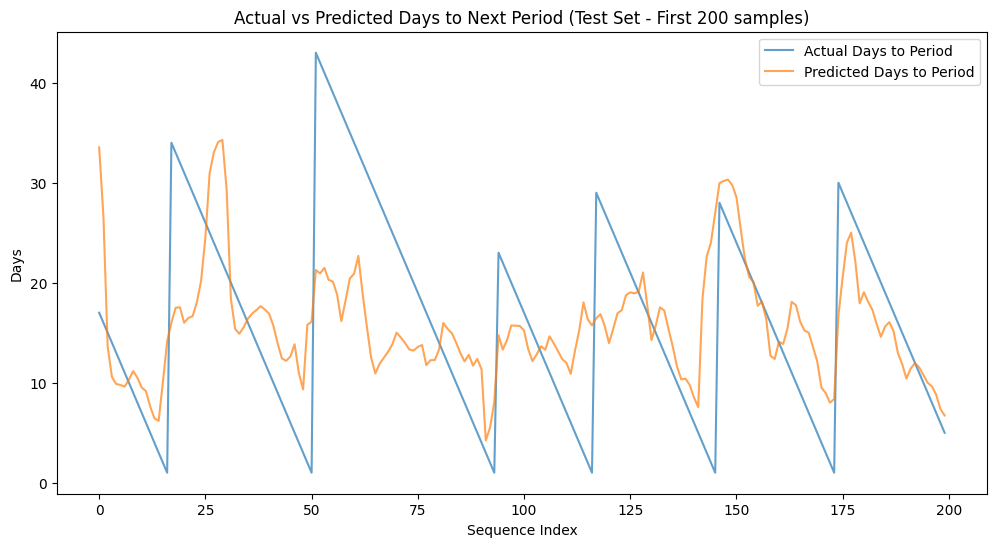

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Split users into train and test
unique_users = df_clean['id'].unique()
np.random.seed(42)
np.random.shuffle(unique_users)

train_users = unique_users[:int(0.8 * len(unique_users))]
test_users = unique_users[int(0.8 * len(unique_users)):]

def get_data_for_users(users):
    X_u, y_u = [], []
    for uid in users:
        user_data = df_clean[df_clean['id'] == uid]
        if len(user_data) > lookback:
            X_seq, y_seq = create_sequences(user_data[features].values,
                                              user_data['days_to_period'].values,
                                              lookback)
            X_u.append(X_seq)
            y_u.append(y_seq)
    return np.concatenate(X_u), np.concatenate(y_u)

X_train, y_train = get_data_for_users(train_users)
X_test, y_test = get_data_for_users(test_users)

# Define LSTM model
model = Sequential([
    LSTM(64, input_shape=(lookback, len(features)), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1) # Predict days remaining
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train model
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1, verbose=0)

# Evaluate
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test MAE: {mae:.2f} days")

# Generate some predictions
y_pred = model.predict(X_test, verbose=0)

# Save the plot of actual vs predicted for a segment
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test[:200], label='Actual Days to Period', alpha=0.7)
plt.plot(y_pred[:200], label='Predicted Days to Period', alpha=0.7)
plt.title('Actual vs Predicted Days to Next Period (Test Set - First 200 samples)')
plt.xlabel('Sequence Index')
plt.ylabel('Days')
plt.legend()
plt.savefig('lstm_prediction_plot.png')

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Define the LSTM architecture
model = Sequential([
    LSTM(64, input_shape=(10, 18), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1) # Output: Days until next period
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1)

Epoch 1/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 162.9933 - mae: 10.0377 - val_loss: 86.7555 - val_mae: 8.0325
Epoch 2/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 101.0918 - mae: 8.3062 - val_loss: 86.6350 - val_mae: 8.0259
Epoch 3/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 100.3297 - mae: 8.2718 - val_loss: 85.6538 - val_mae: 7.9647
Epoch 4/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 100.4782 - mae: 8.2765 - val_loss: 85.6694 - val_mae: 7.9657
Epoch 5/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 99.9021 - mae: 8.2319 - val_loss: 88.0759 - val_mae: 8.1025
Epoch 6/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 100.0571 - mae: 8.2852 - val_loss: 85.4755 - val_mae: 7.9513
Epoch 7/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 99.6710 - mae: 8.2379 - val_loss: 86.1381 - val_mae: 7.9963
Epoch 8/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 99.9121 - mae: 8.2748 - val_loss: 86.3057 - val_mae: 8.0059
Epoch 9/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/s